# GWAS on Diseased donors — WGS data

Same analysis as `metric_corr_with_GWAS_only_diseased_XDP.ipynb`, split into prep + run
(mirrors the GSA split: `GSA_XDP_01_prepare_for_GWAS.ipynb` / `GSA_XDP_02_run_GWAS.ipynb`).
The genotype-side prep (candidate-region VCF, ancestry PCA, kinship) is done by
[`WGS_XDP_01_prepare_for_GWAS.ipynb`](WGS_XDP_01_prepare_for_GWAS.ipynb) — this notebook
picks up from its outputs (`subset/candidate.norm.bcf`, `whole_xdp_PCA/PCA.eigenvec`) and
computes the phenotype + runs the regression.

trait ~ allele_dosage + PCs + sex + Age + d1d2_z2_cov


## Load snRNA-seq data and select cell types

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
adata = sc.read_h5ad("/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_+_NucSeq.h5ad", backed="r")
adata


AnnData object with n_obs × n_vars = 768735 × 35576 backed at '/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_+_NucSeq.h5ad'
    obs: 'x', 'y', 'has_spatial', 'pct_intronic', 'Neighborhood_name', 'Class_name', 'Subclass_name', 'Subclass_bootstrapping_probability', 'Subclass_aggregate_probability', 'Group_name', 'Group_bootstrapping_probability', 'Group_aggregate_probability', 'donor_id', 'bcl', 'library', 'library_id', 'Sorted', 'mapping_coupling_for_zoning', 'zone', 'zone_probability', 'mapping_coupling_for_zoning_4_zones', 'zone_4', 'zone_4_probability', 'ct_for_deg', 'is_neuron', 'dataset', 'sample', 'is_Mito_cluster_matrix', 'is_mito_cluster_patch', 'puck', 'region', 'radial_high_mito_patch', 'radial_patch_in_death', 'radial_patch_in_healthy', 'mito_radial_neighborhood', 'original_donor_id', 'sex', 'condition', 'cohort', 'rqs', 'dv200', 'mqs_numerical', 'mqs', 'ph', 'brain_bank', 'year_collected', 'repeat_length', 'repeat_length_notes', 'age_of_onset', 'age_of_de

In [3]:
obs = adata.obs.copy()

# select only nucseq dataset
obs = obs[obs["dataset"] == "nucseq"].copy()

# map cell types
obs["ct"] = obs["ct_for_deg"].map({
    "eMSN_D1D2": "eMSN_D1D2", "Matrix_D1": "Matrix", "Matrix_D2": "Matrix",
    "Patch_D1": "Patch", "Patch_D2": "Patch"
}).fillna(obs["ct_for_deg"])

# select specific cell types
obs = obs[obs["ct_for_deg"].isin(["eMSN_D1D2", "Matrix_D1", "Matrix_D2"])].copy()

obs


,x,y,has_spatial,pct_intronic,Neighborhood_name,Class_name,Subclass_name,Subclass_bootstrapping_probability,Subclass_aggregate_probability,Group_name,...,year_collected,repeat_length,repeat_length_notes,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,image,ct
44357,NaN,NaN,False,0.729263,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,0.94,0.94,STR D1D2 Hybrid MSN,...,2023,0,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,NaN,eMSN_D1D2
44358,NaN,NaN,False,0.762042,Subpallium GABA,CN LGE GABA,STR D1 MSN,1.00,1.00,STRv D1 MSN,...,2018,41,NaN,41,56,15,615.0,Pnuemonia,NaN,Matrix
44359,NaN,NaN,False,0.785992,Subpallium GABA,CN LGE GABA,STR D1 MSN,1.00,1.00,STRv D1 MSN,...,2020,38,NaN,51,54,3,114.0,Septicemia,NaN,Matrix
44364,NaN,NaN,False,0.763846,Subpallium GABA,CN LGE GABA,STR D1 MSN,1.00,1.00,STRd D1 Matrix MSN,...,2022,0,NaN,not_applicable,66,not_applicable,0.0,Myocardial Infarction O2 - few hrs,NaN,Matrix
44374,NaN,NaN,False,0.737400,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,0.85,0.85,STR D1D2 Hybrid MSN,...,2023,0,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,NaN,eMSN_D1D2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99434,NaN,NaN,False,0.734533,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STR D1D2 Hybrid MSN,...,2022,46,NaN,NaN,46,NaN,NaN,Acute Respiratory Failure,NaN,eMSN_D1D2
99471,NaN,NaN,False,0.722178,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STR D1D2 Hybrid MSN,...,2023,41,NaN,39,49,10,410.0,Acute Respiratory Macular Paralysis,NaN,eMSN_D1D2
99503,NaN,NaN,False,0.795778,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STRv D1 NUDAP MSN,...,2022,46,NaN,NaN,46,NaN,NaN,Acute Respiratory Failure,NaN,eMSN_D1D2
99517,NaN,NaN,False,0.784605,Subpallium GABA,CN LGE GABA,STR Hybrid MSN,1.00,1.00,STR D1D2 Hybrid MSN,...,2019,43,NaN,36,51,15,645.0,Dystonia,NaN,eMSN_D1D2


## Build per-donor metadata table

In [4]:
# make a sample of the nucseq dataset with only one observation per donor
df_meta = obs.drop_duplicates(subset=["donor_id"], keep="first")

df_meta = df_meta[[
       'original_donor_id', 'sex', 'condition', 'cohort', 'rqs', 'dv200',
       'mqs_numerical', 'mqs', 'ph', 'brain_bank', 'year_collected',
       'repeat_length', 'repeat_length_notes', 'age_of_onset', 'age_of_death',
       'disease_duration', 'cap', 'immediate_cause_of_death', 'donor_id']]

df_meta.set_index("donor_id", inplace=True)
df_meta["donor_id"] = df_meta.index

df_meta["m1_z1_raw_trait"] = np.nan
df_meta["m1_z1_trait"] = np.nan
df_meta["d1d1_z2_cov"] = np.nan

donors_from_adata_nucseq = adata[adata.obs["dataset"] == "nucseq"].obs["original_donor_id"].unique().tolist()
print(donors_from_adata_nucseq)
print(len(donors_from_adata_nucseq))

df_meta


['SCF-20-025', 'SCF-22-054CM', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'PCMC-16-011', 'SCF-22-058CF', 'SCF-18-004', 'SCF-20-023', 'SCF_21-037CM2', 'SCF-23-068CM', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_22_049CCF', 'SCF_22_063CM', 'SCF_23_074CF', 'SCF_21_041', 'SCF_21_034', 'SCF_22_067CM', 'SCF_23_079CF', 'SCF_22_065CM', 'SCF_23_075CM', 'SCF_23_072CF', 'SCF_22-050CM6', 'SCF_22-048', 'SCF_20-026', 'SCF_22-046CF', 'SCF_22-057CM', 'SCF_22-056CF', 'SCF-22-045', 'SCF_23-081CM', 'SCF-22-044', 'SCF-19-020', 'SCF-22-042', 'SCF_22-052', 'SCF_23-083', 'SCF_22-060', 'SCF_23-080']
47


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,repeat_length_notes,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-23-068,SCF-23-068CM,M,Control,C_1,6.30,0.76,4.0,B,6.0,SCF,...,NaN,not_applicable,43,not_applicable,0.0,Myocardial Infraction,SCF-23-068,NaN,NaN,NaN
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,NaN,41,56,15,615.0,Pnuemonia,SCF-18-004,NaN,NaN,NaN
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,NaN,51,54,3,114.0,Septicemia,SCF-20-025,NaN,NaN,NaN
SCF-22-058,SCF-22-058CF,F,Control,C_1,5.79,0.72,2.0,D Redo,6.0,SCF,...,NaN,not_applicable,66,not_applicable,0.0,Myocardial Infarction O2 - few hrs,SCF-22-058,NaN,NaN,NaN
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,NaN,30,43,13,598.0,Myocardial Infraction,SCF-21-030,NaN,NaN,NaN
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,NaN,32,41,9,378.0,"Pnuemonia, Dystonia",SCF-18-003,NaN,NaN,NaN
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,"42, 46 (mosaic)",38,41,3,132.0,Myocardial Infraction,SCF-20-023,NaN,NaN,NaN
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,NaN,49,54,5,195.0,Pnuemonia,SCF-19-009,NaN,NaN,NaN
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,NaN,39,46,7,322.0,Probable Myocardial Infarction,SCF-20-024,NaN,NaN,NaN


## Calculate trait

In [5]:
from scipy.stats import norm

def rint(series):
    """Rank-based inverse-normal transform (Blom), NaN-safe."""
    x = series.copy()
    mask = x.notna()                      # ignore donors with no value
    ranks = x[mask].rank(method="average")
    n = mask.sum()
    # Blom offset c = 3/8 is the standard choice
    x[mask] = norm.ppf((ranks - 3/8) / (n - 2*3/8 + 1))
    return x

for donor in df_meta["donor_id"].unique():

    obs_donor = obs[obs["donor_id"] == donor]

    n_m1_total = len(obs_donor[obs_donor["ct_for_deg"] == "Matrix_D1"])
    n_m1_z1    = len(obs_donor[(obs_donor["ct_for_deg"] == "Matrix_D1") & (obs_donor["zone"] == "1")])

    n_espn_total = len(obs_donor[obs_donor["ct_for_deg"] == "eMSN_D1D2"])
    n_espn_z2    = len(obs_donor[(obs_donor["ct_for_deg"] == "eMSN_D1D2") & (obs_donor["zone_4"] == "2")])

    print(f"donor {donor}: n_m1_total={n_m1_total}, n_m1_z1={n_m1_z1}, n_espn_total={n_espn_total}, n_espn_z2={n_espn_z2}")

    # guard against donors with zero matrix-D1 cells -> NaN instead of crash
    df_meta.loc[donor, "n_m1_total"]        = n_m1_total
    df_meta.loc[donor, "m1_z1_raw_trait"]   = n_m1_z1 / n_m1_total if n_m1_total > 0 else np.nan
    df_meta.loc[donor, "d1d1_z2_cov"]       = n_espn_z2 / n_espn_total if n_espn_total > 0 else np.nan

# AFTER the loop: transform the whole column at once
df_meta["m1_z1_trait"] = rint(df_meta["m1_z1_raw_trait"])

df_meta


donor SCF-23-068: n_m1_total=386, n_m1_z1=57, n_espn_total=72, n_espn_z2=29
donor SCF-18-004: n_m1_total=41, n_m1_z1=0, n_espn_total=37, n_espn_z2=4
donor SCF-20-025: n_m1_total=369, n_m1_z1=5, n_espn_total=143, n_espn_z2=35
donor SCF-22-058: n_m1_total=477, n_m1_z1=65, n_espn_total=70, n_espn_z2=26
donor SCF-21-030: n_m1_total=66, n_m1_z1=2, n_espn_total=57, n_espn_z2=17
donor SCF-18-003: n_m1_total=164, n_m1_z1=0, n_espn_total=156, n_espn_z2=36
donor SCF-20-023: n_m1_total=160, n_m1_z1=5, n_espn_total=52, n_espn_z2=16
donor SCF-19-009: n_m1_total=137, n_m1_z1=4, n_espn_total=57, n_espn_z2=17
donor SCF-20-024: n_m1_total=272, n_m1_z1=1, n_espn_total=90, n_espn_z2=13
donor SCF-22-054: n_m1_total=434, n_m1_z1=73, n_espn_total=69, n_espn_z2=24
donor SCF-22-043: n_m1_total=84, n_m1_z1=1, n_espn_total=73, n_espn_z2=10
donor SCF-19-018: n_m1_total=179, n_m1_z1=0, n_espn_total=48, n_espn_z2=5
donor SCF-19-014: n_m1_total=180, n_m1_z1=10, n_espn_total=71, n_espn_z2=29
donor SCF-21-037: n_m1_t

,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-23-068,SCF-23-068CM,M,Control,C_1,6.30,0.76,4.0,B,6.0,SCF,...,not_applicable,43,not_applicable,0.0,Myocardial Infraction,SCF-23-068,0.147668,0.828465,0.402778,386.0
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,41,56,15,615.0,Pnuemonia,SCF-18-004,0.000000,-0.946457,0.108108,41.0
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,51,54,3,114.0,Septicemia,SCF-20-025,0.013550,-0.106301,0.244755,369.0
SCF-22-058,SCF-22-058CF,F,Control,C_1,5.79,0.72,2.0,D Redo,6.0,SCF,...,not_applicable,66,not_applicable,0.0,Myocardial Infarction O2 - few hrs,SCF-22-058,0.136268,0.687031,0.371429,477.0
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,30,43,13,598.0,Myocardial Infraction,SCF-21-030,0.030303,0.026528,0.298246,66.0
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,32,41,9,378.0,"Pnuemonia, Dystonia",SCF-18-003,0.000000,-0.946457,0.230769,164.0
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,38,41,3,132.0,Myocardial Infraction,SCF-20-023,0.031250,0.106301,0.307692,160.0
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,49,54,5,195.0,Pnuemonia,SCF-19-009,0.029197,-0.053075,0.298246,137.0
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,39,46,7,322.0,Probable Myocardial Infarction,SCF-20-024,0.003676,-0.380326,0.144444,272.0


### Analyse

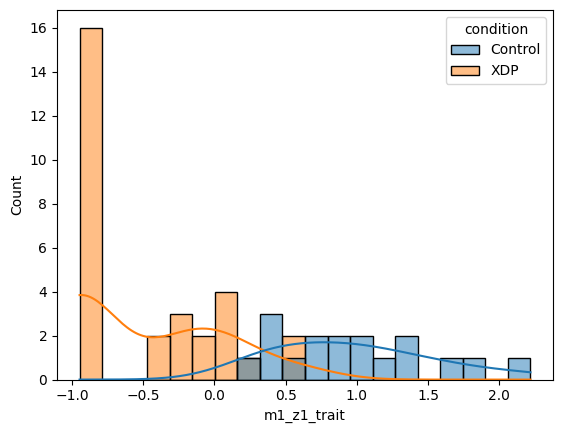

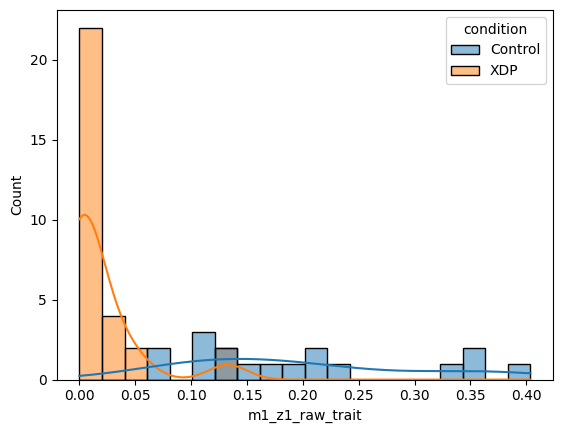

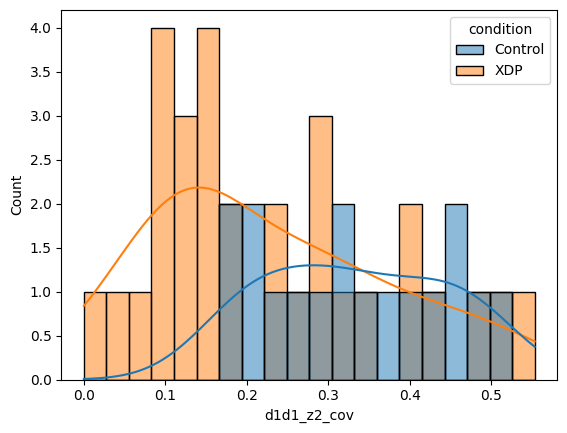

In [6]:
sns.histplot(data=df_meta, x="m1_z1_trait", bins=20, kde=True, hue="condition"); plt.show()
sns.histplot(data=df_meta, x="m1_z1_raw_trait", bins=20, kde=True, hue="condition"); plt.show()
sns.histplot(data=df_meta, x="d1d1_z2_cov", bins=20, kde=True, hue="condition"); plt.show()


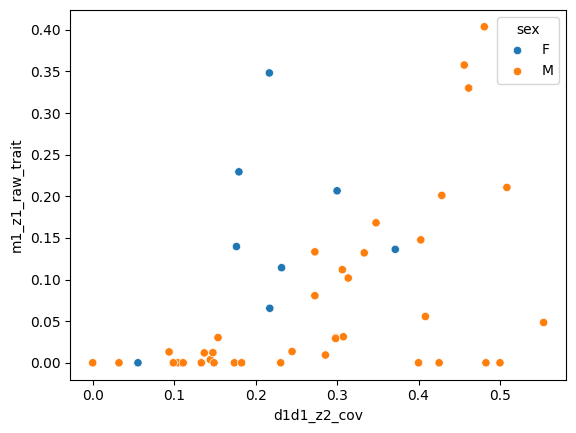

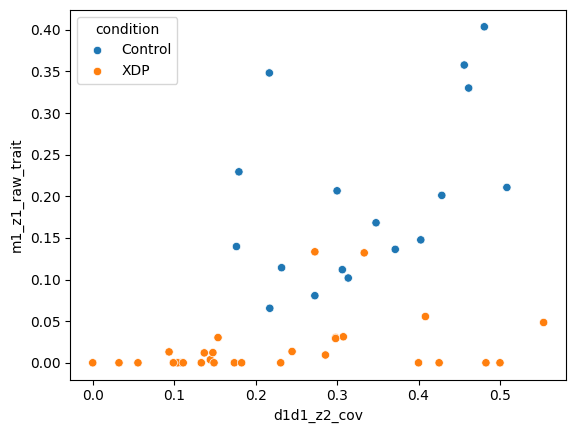

In [7]:
sns.scatterplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="sex"); plt.show()
sns.scatterplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="condition"); plt.show()


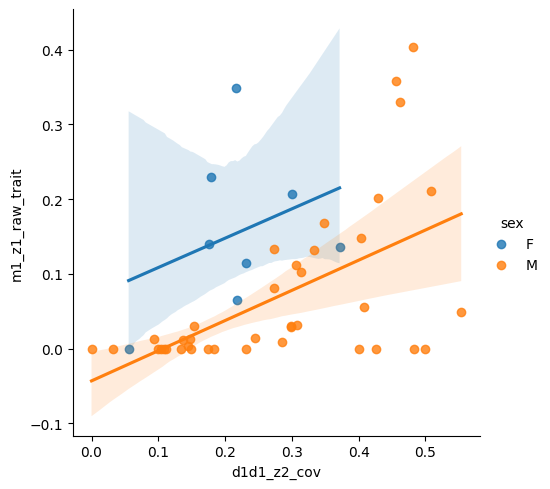

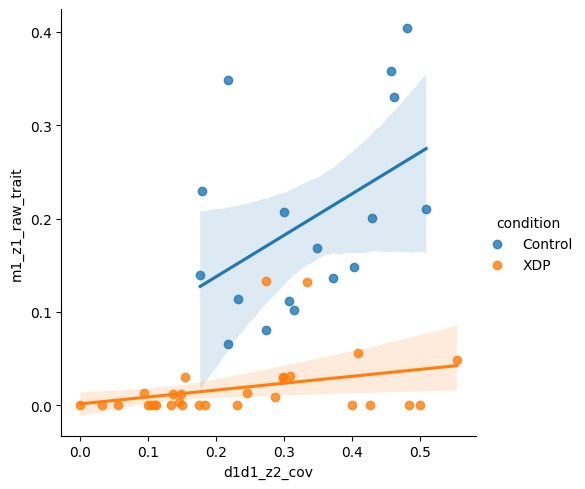

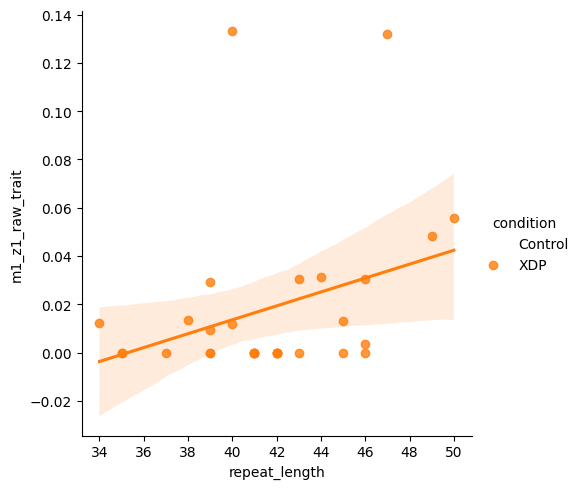

In [8]:
sns.lmplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="sex"); plt.show()
sns.lmplot(data=df_meta, x="d1d1_z2_cov", y="m1_z1_raw_trait", hue="condition"); plt.show()
sns.lmplot(data=df_meta[df_meta["condition"] == "XDP"], x="repeat_length", y="m1_z1_raw_trait", hue="condition"); plt.show()


### Filter to Diseased + Male donors for GWAS

In [9]:
df_meta_diseased = df_meta[
        (df_meta["condition"] == "XDP") &
        (df_meta["sex"] == "M")
        ].copy()

display(df_meta_diseased)

for var in ["age_of_onset", "age_of_death", "disease_duration", "repeat_length"]:
    numeric_var = pd.to_numeric(df_meta_diseased[var], errors="coerce")  # 'not_applicable' -> NaN
    corr = df_meta_diseased["m1_z1_trait"].corr(numeric_var, method="spearman")
    print(f"Correlation between m1_z1_trait and {var}: {corr:.4f}")

donors_from_adata_nucseq_male_diseased = adata[
    (adata.obs["dataset"] == "nucseq") &
    (adata.obs["condition"] == "XDP") &
    (adata.obs["sex"] == "M")
].obs["original_donor_id"].unique().tolist()
print(donors_from_adata_nucseq_male_diseased)


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,age_of_onset,age_of_death,disease_duration,cap,immediate_cause_of_death,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,41,56,15,615.0,Pnuemonia,SCF-18-004,0.000000,-0.946457,0.108108,41.0
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,51,54,3,114.0,Septicemia,SCF-20-025,0.013550,-0.106301,0.244755,369.0
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,30,43,13,598.0,Myocardial Infraction,SCF-21-030,0.030303,0.026528,0.298246,66.0
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,32,41,9,378.0,"Pnuemonia, Dystonia",SCF-18-003,0.000000,-0.946457,0.230769,164.0
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,38,41,3,132.0,Myocardial Infraction,SCF-20-023,0.031250,0.106301,0.307692,160.0
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,49,54,5,195.0,Pnuemonia,SCF-19-009,0.029197,-0.053075,0.298246,137.0
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,39,46,7,322.0,Probable Myocardial Infarction,SCF-20-024,0.003676,-0.380326,0.144444,272.0
SCF-22-043,SCF_22-043,M,XDP,C_1,6.83,0.82,4.0,B,NaN,SCF,...,46,52,6,240.0,Myocardial Infarction,SCF-22-043,0.011905,-0.268441,0.136986,84.0
SCF-19-018,SCF-19-018,M,XDP,C_1,6.78,0.78,4.0,B,6.0,SCF,...,33,40,7,315.0,Dystonia,SCF-19-018,0.000000,-0.946457,0.104167,179.0


Correlation between m1_z1_trait and age_of_onset: -0.0075
Correlation between m1_z1_trait and age_of_death: -0.0712
Correlation between m1_z1_trait and disease_duration: -0.3178
Correlation between m1_z1_trait and repeat_length: 0.3058
['SCF-20-025', 'SCF-19-009', 'SCF-18-006', 'SCF_20-024', 'SCF_22-043', 'SCF-18-003', 'SCF-19-018', 'SCF-19-014', 'SCF-21-030', 'SCF-18-004', 'SCF-20-023', 'PCMC-16-012', 'SCF_23_070_MMC', 'SCF_21_027', 'SCF_21_038', 'SCF_21_029', 'SCF_21_032', 'SCF_21_041', 'SCF_21_034', 'SCF_22-048', 'SCF_20-026', 'SCF-22-045', 'SCF-22-044', 'SCF-19-020', 'SCF-22-042', 'SCF_22-052', 'SCF_23-083', 'SCF_22-060', 'SCF_23-080']


## WGS genotype inputs

Everything up to this point is identical to the monolithic notebook. From here on, instead of
rebuilding the candidate-region VCF and ancestry PCA from scratch (contig check, gene BED
lookup, donor-ID intersection, chrom rename, `bcftools norm`, PCA, kinship), we load the
already-prepared WGS outputs directly from
[`WGS_XDP_01_prepare_for_GWAS.ipynb`](WGS_XDP_01_prepare_for_GWAS.ipynb):

- `subset/candidate.norm.bcf` — candidate-region (`MSH3`, `PMS2`) genotypes, already subset to
  the male+XDP donors matched to the VCF, chromosome-renamed, and normalized.
- `whole_xdp_PCA/PCA.eigenvec` — ancestry PCs, computed on the full WGS cohort.


In [10]:
import subprocess, os

VCF_FOLDER = "/home/gdallagl/myworkdir/XDP/data/XDP/vcf"
MOUNT = VCF_FOLDER

IMAGE_BCFTOOLS = "quay.io/biocontainers/bcftools:1.21--h8b25389_0"
IMAGE_PLINK    = "quay.io/biocontainers/plink2:2.0.0a.6.9--h9948957_0"
N_THREADS = 16

def bcftools(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_BCFTOOLS, "bcftools", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    if check and p.returncode != 0:
        raise RuntimeError(f"bcftools {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr

def plink2(args, check=True):
    cmd = ["podman", "run", "--rm", "-w", "/data", "-v", f"{MOUNT}:/data", IMAGE_PLINK, "plink2", *args]
    p = subprocess.run(cmd, capture_output=True, text=True)
    print(p.stdout[-2000:])
    if check and p.returncode != 0:
        raise RuntimeError(f"plink2 {' '.join(args)} failed:\n{p.stderr}")
    return p.stdout, p.stderr

SUBSET_NORM_VCF = "subset/candidate.norm.bcf"   # from WGS_XDP_01_prepare_for_GWAS.ipynb
PLINK_INFLAG    = "--bcf"
SUBSET_PGEN     = "subset/plink/candidate"

PCA_OUT = "whole_xdp_PCA/PCA"                    # from WGS_XDP_01_prepare_for_GWAS.ipynb

os.makedirs(f"{VCF_FOLDER}/subset/plink", exist_ok=True)
os.makedirs(f"{VCF_FOLDER}/subset/gwas_input_covs", exist_ok=True)
os.makedirs(f"{VCF_FOLDER}/subset/results", exist_ok=True)


### Convert candidate-region VCF to plink2 + QC

In [11]:
# 4a. Convert VCF/BCF to plink2 binary (.pgen / .pvar / .psam)
plink2([PLINK_INFLAG, SUBSET_NORM_VCF,
        "--set-all-var-ids", "@:#:$r:$a",             # assign a deterministic ID to every variant
        "--new-id-max-allele-len", "100", "missing",  # alleles longer than 100bp -> ID "missing"
        "--make-pgen", "--out", SUBSET_PGEN, "--threads", str(N_THREADS)])

# 4b. Quality-control the plink file
plink2(["--pfile", SUBSET_PGEN,
        "--geno", "0.05",   # remove variants missing in >5% of samples (unreliable calls)
        "--mind", "0.1",    # remove samples missing >10% of variants (poor sequencing)
        "--maf", "0.05",    # keep only common variants (MAF >= 5%)
        "--make-pgen", "--out", f"{SUBSET_PGEN}_qc", "--threads", str(N_THREADS)])


sing
  --out subset/plink/candidate
  --set-all-var-ids @:#:$r:$a
  --threads 16

Start time: Thu Jul 16 01:05:11 2026
314189 MiB RAM detected, ~243892 available; reserving 157094 MiB for main
workspace.
Using up to 16 threads (change this with --threads).

--bcf: 234 variants scanned.

--bcf: 0k variants converted.  
--bcf: subset/plink/candidate-temporary.pgen +
subset/plink/candidate-temporary.pvar.zst +
subset/plink/candidate-temporary.psam written.
13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from
subset/plink/candidate-temporary.psam.
234 variants loaded from subset/plink/candidate-temporary.pvar.zst.
Note: No phenotype data present.
Writing subset/plink/candidate.psam ... done.
Writing subset/plink/candidate.pvar ... 10101111121213131414151516161717181819192020212122222323242425252626272728282929303031313232333334343535363637373838393940404141424243434444454546464747484849505051515252535354545555565657575858595960606161626263636464656566666767686869697070717

('PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to subset/plink/candidate_qc.log.\nOptions in effect:\n  --geno 0.05\n  --maf 0.05\n  --make-pgen\n  --mind 0.1\n  --out subset/plink/candidate_qc\n  --pfile subset/plink/candidate\n  --threads 16\n\nStart time: Thu Jul 16 01:05:12 2026\n314189 MiB RAM detected, ~243912 available; reserving 157094 MiB for main\nworkspace.\nUsing up to 16 threads (change this with --threads).\n13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from\nsubset/plink/candidate.psam.\n234 variants loaded from subset/plink/candidate.pvar.\nNote: No phenotype data present.\nCalculating sample missingness rates... 0%\x08\x08done.\n0 samples removed due to missing genotype data (--mind).\n13 samples (0 females, 0 males, 13 ambiguous; 13 founders) remaining after main\nfilters.\nCalculating allele frequencies... 0%\x08\x08done.\n--g

### Load ancestry PCs

In [12]:
pcs = pd.read_csv(f"{VCF_FOLDER}/{PCA_OUT}.eigenvec", sep=r"\s+")
pcs.columns = [c.lstrip("#") for c in pcs.columns]
print(f"Loaded ancestry PCs for {len(pcs)} donors (computed in WGS_XDP_01_prepare_for_GWAS.ipynb)")
pcs.head()


Loaded ancestry PCs for 31 donors (computed in WGS_XDP_01_prepare_for_GWAS.ipynb)


,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,PCMC-16-011,0.145423,-0.117074,0.220676,0.033199,0.082611,0.194314,0.086305,-0.002521,0.230084,-0.221438
1,PCMC-16-012,0.151813,-0.144165,0.161088,0.064444,-0.014435,0.067784,-0.065121,0.206288,0.068751,-0.099444
2,PCMC_17-005,0.078685,0.002348,0.151297,-0.005681,0.141958,0.126402,-0.420942,0.042715,-0.149866,-0.114692
3,PCMC_17-010,0.007593,-0.044759,-0.291861,0.037569,-0.201474,0.048006,0.246662,-0.051078,-0.146609,0.041620
4,PCMC_17-012,0.042215,-0.052705,0.072862,0.522853,0.054095,0.144296,0.062331,0.212627,0.323961,0.240715


## Prepare GWAS Input Files

Merge the snRNA-seq trait, clinical covariates, and ancestry PCs, then write
two plain-text files that plink2 expects:

- **pheno.txt** — `IID  m1_z1_trait` (rank-normalised)
- **covar.txt** — `IID  d1d1_z2_cov  age  sex_num  PC1  PC2  PC3`

In [13]:
df_gwas = df_meta_diseased.copy()

# Encode sex as integer: plink2 convention = 1 male, 2 female
sex_map = {"M": 1, "male": 1, "F": 2, "female": 2}
df_gwas["sex_num"] = df_gwas["sex"].map(sex_map)

# age_of_death is the only age variable always defined for all donors.
df_gwas["age"] = pd.to_numeric(df_gwas["age_of_death"], errors="coerce")

# Merge ancestry PCs: IID in pcs matches donor_id in df_gwas via original_donor_id.
df_gwas = df_gwas.merge(
    pcs.set_index("IID")[["PC1", "PC2", "PC3"]],
    left_on="original_donor_id",
    right_index=True,
    how="left"
)

display(df_gwas)

# Drop any donor missing the trait, PCs, age, sex, or the cell-type covariate.
df_gwas = df_gwas.dropna(
    subset=["m1_z1_trait", "d1d1_z2_cov", "age", "sex_num", "PC1"]
)

display(df_gwas)

# IID column must match VCF sample names exactly for plink to link files.
df_gwas["IID"] = df_gwas["original_donor_id"]

print(f"Final GWAS N = {len(df_gwas)} donors")
display(df_gwas[["IID","m1_z1_trait","d1d1_z2_cov","age","sex_num","PC1","PC2","PC3"]])

TRAIT     = "m1_z1_trait"
COVS      = ["d1d1_z2_cov", "age"] # "sex_num"] # "PC1", "PC2", "PC3"]
PHENO_FILE   = "subset/gwas_input_covs/pheno.txt"
COVAR_FILE   = "subset/gwas_input_covs/covar.txt"
RESULTS_FILE = "subset/results/results"

pheno = df_gwas[["IID", TRAIT]]
pheno.to_csv(f"{VCF_FOLDER}/{PHENO_FILE}", sep="\t", index=False, na_rep="NA")
print(f"\nPhenotype file written -> {PHENO_FILE}  ({len(pheno)} rows)")

covar = df_gwas[["IID"] + COVS]
covar.to_csv(f"{VCF_FOLDER}/{COVAR_FILE}", sep="\t", index=False, na_rep="NA")
print(f"Covariate file written  -> {COVAR_FILE}  (covariates: {COVS})")


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total,sex_num,age,PC1,PC2,PC3
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,SCF-18-004,0.000000,-0.946457,0.108108,41.0,1,56,-0.054080,0.217810,0.219315
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,SCF-20-025,0.013550,-0.106301,0.244755,369.0,1,54,0.038035,-0.576789,-0.109981
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,SCF-21-030,0.030303,0.026528,0.298246,66.0,1,43,-0.524913,0.037219,0.159795
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,SCF-18-003,0.000000,-0.946457,0.230769,164.0,1,41,0.077991,0.208763,-0.155861
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,SCF-20-023,0.031250,0.106301,0.307692,160.0,1,41,-0.610642,-0.087810,0.019443
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,SCF-19-009,0.029197,-0.053075,0.298246,137.0,1,54,0.052972,-0.145604,0.134704
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,SCF-20-024,0.003676,-0.380326,0.144444,272.0,1,46,-0.121999,0.022155,0.061453
SCF-22-043,SCF_22-043,M,XDP,C_1,6.83,0.82,4.0,B,NaN,SCF,...,SCF-22-043,0.011905,-0.268441,0.136986,84.0,1,52,0.125397,-0.064838,0.309777
SCF-19-018,SCF-19-018,M,XDP,C_1,6.78,0.78,4.0,B,6.0,SCF,...,SCF-19-018,0.000000,-0.946457,0.104167,179.0,1,40,-0.002132,0.203320,0.131776


,original_donor_id,sex,condition,cohort,rqs,dv200,mqs_numerical,mqs,ph,brain_bank,...,donor_id,m1_z1_raw_trait,m1_z1_trait,d1d1_z2_cov,n_m1_total,sex_num,age,PC1,PC2,PC3
donor_id,,,,,,,,,,,,,,,,,,,,,
SCF-18-004,SCF-18-004,M,XDP,C_1,6.97,0.78,4.5,AB,6.0,SCF,...,SCF-18-004,0.000000,-0.946457,0.108108,41.0,1,56,-0.054080,0.217810,0.219315
SCF-20-025,SCF-20-025,M,XDP,C_1,6.50,0.74,5.0,A,6.0,SCF,...,SCF-20-025,0.013550,-0.106301,0.244755,369.0,1,54,0.038035,-0.576789,-0.109981
SCF-21-030,SCF-21-030,M,XDP,C_1,6.74,0.80,5.0,A,6.2,SCF,...,SCF-21-030,0.030303,0.026528,0.298246,66.0,1,43,-0.524913,0.037219,0.159795
SCF-18-003,SCF-18-003,M,XDP,C_1,6.92,0.79,5.0,A,6.4,SCF,...,SCF-18-003,0.000000,-0.946457,0.230769,164.0,1,41,0.077991,0.208763,-0.155861
SCF-20-023,SCF-20-023,M,XDP,C_1,6.71,0.81,5.0,A,6.0,SCF,...,SCF-20-023,0.031250,0.106301,0.307692,160.0,1,41,-0.610642,-0.087810,0.019443
SCF-19-009,SCF-19-009,M,XDP,C_1,5.34,0.72,4.5,AB,6.0,SCF,...,SCF-19-009,0.029197,-0.053075,0.298246,137.0,1,54,0.052972,-0.145604,0.134704
SCF-20-024,SCF_20-024,M,XDP,C_1,7.21,0.85,4.0,B,NaN,SCF,...,SCF-20-024,0.003676,-0.380326,0.144444,272.0,1,46,-0.121999,0.022155,0.061453
SCF-22-043,SCF_22-043,M,XDP,C_1,6.83,0.82,4.0,B,NaN,SCF,...,SCF-22-043,0.011905,-0.268441,0.136986,84.0,1,52,0.125397,-0.064838,0.309777
SCF-19-018,SCF-19-018,M,XDP,C_1,6.78,0.78,4.0,B,6.0,SCF,...,SCF-19-018,0.000000,-0.946457,0.104167,179.0,1,40,-0.002132,0.203320,0.131776


Final GWAS N = 13 donors


,IID,m1_z1_trait,d1d1_z2_cov,age,sex_num,PC1,PC2,PC3
donor_id,,,,,,,,
SCF-18-004,SCF-18-004,-0.946457,0.108108,56,1,-0.054080,0.217810,0.219315
SCF-20-025,SCF-20-025,-0.106301,0.244755,54,1,0.038035,-0.576789,-0.109981
SCF-21-030,SCF-21-030,0.026528,0.298246,43,1,-0.524913,0.037219,0.159795
SCF-18-003,SCF-18-003,-0.946457,0.230769,41,1,0.077991,0.208763,-0.155861
SCF-20-023,SCF-20-023,0.106301,0.307692,41,1,-0.610642,-0.087810,0.019443
SCF-19-009,SCF-19-009,-0.053075,0.298246,54,1,0.052972,-0.145604,0.134704
SCF-20-024,SCF_20-024,-0.380326,0.144444,46,1,-0.121999,0.022155,0.061453
SCF-22-043,SCF_22-043,-0.268441,0.136986,52,1,0.125397,-0.064838,0.309777
SCF-19-018,SCF-19-018,-0.946457,0.104167,40,1,-0.002132,0.203320,0.131776



Phenotype file written -> subset/gwas_input_covs/pheno.txt  (13 rows)
Covariate file written  -> subset/gwas_input_covs/covar.txt  (covariates: ['d1d1_z2_cov', 'age'])


### Run Linear GWAS

For every variant in the QC-filtered candidate region, plink2 fits:

```
m1_z1_trait ~ ALT_dosage + d1d1_z2_cov + age + sex_num + PC1 + PC2 + PC3
```

- `ALT_dosage` is the additive genotype (0/1/2 copies of the ALT allele)
- Trait is rank-normalised -> residuals are approximately Normal (OLS valid)
- `--covar-variance-standardize` z-scores covariates so BETAs are on comparable scales

In [14]:
plink2(["--pfile", f"{SUBSET_PGEN}_qc",
        "--pheno", PHENO_FILE, "--pheno-name", TRAIT,
        "--covar", COVAR_FILE, "--covar-name", ",".join(COVS),
        "--glm", "hide-covar",              # OLS per variant; hide-covar drops covariate rows
        "--covar-variance-standardize",     # z-score all covariates before fitting
        "--out", RESULTS_FILE])


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to subset/results/results.log.
Options in effect:
  --covar subset/gwas_input_covs/covar.txt
  --covar-name d1d1_z2_cov,age
  --covar-variance-standardize
  --glm hide-covar
  --out subset/results/results
  --pfile subset/plink/candidate_qc
  --pheno subset/gwas_input_covs/pheno.txt
  --pheno-name m1_z1_trait

Start time: Thu Jul 16 01:05:12 2026
314189 MiB RAM detected, ~243915 available; reserving 157094 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from
subset/plink/candidate_qc.psam.
177 variants loaded from subset/plink/candidate_qc.pvar.
1 quantitative phenotype loaded (13 values).
2 covariates loaded from subset/gwas_input_covs/covar.txt.
--covar-variance-standardize: 2 covariates transformed.
Calculating allele frequenc

("PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to subset/results/results.log.\nOptions in effect:\n  --covar subset/gwas_input_covs/covar.txt\n  --covar-name d1d1_z2_cov,age\n  --covar-variance-standardize\n  --glm hide-covar\n  --out subset/results/results\n  --pfile subset/plink/candidate_qc\n  --pheno subset/gwas_input_covs/pheno.txt\n  --pheno-name m1_z1_trait\n\nStart time: Thu Jul 16 01:05:12 2026\n314189 MiB RAM detected, ~243915 available; reserving 157094 MiB for main\nworkspace.\nUsing up to 48 threads (change this with --threads).\n13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from\nsubset/plink/candidate_qc.psam.\n177 variants loaded from subset/plink/candidate_qc.pvar.\n1 quantitative phenotype loaded (13 values).\n2 covariates loaded from subset/gwas_input_covs/covar.txt.\n--covar-variance-standardize: 2 covariates transformed.\nCa

### Load, filter, and visualise GWAS results

Total variants tested: 177
Testable variants (MAF > 10%, non-NaN p): 177

Top 10 associations:


,#CHROM,POS,ID,REF,ALT,PROVISIONAL_REF?,A1,OMITTED,A1_FREQ,TEST,OBS_CT,BETA,SE,T_STAT,P,ERRCODE
82,5,80751257,5:80751257:A:C,A,C,N,A,C,0.423077,ADD,13,0.346730,0.142947,2.42558,0.038259,.
118,5,80839094,5:80839094:C:T,C,T,N,T,C,0.384615,ADD,13,0.317514,0.147136,2.15796,0.059264,.
114,5,80832109,5:80832109:CAAAAAACA:C,CAAAAAACA,C,N,C,CAAAAAACA,0.384615,ADD,13,0.317514,0.147136,2.15796,0.059264,.
130,5,80875315,5:80875315:A:G,A,G,N,A,G,0.384615,ADD,13,0.317514,0.147136,2.15796,0.059264,.
61,5,80723353,5:80723353:A:G,A,G,N,G,A,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
51,5,80711932,5:80711932:G:T,G,T,N,T,G,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
55,5,80717053,5:80717053:G:C,G,C,N,C,G,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
27,5,80681685,5:80681685:GTCAA:G,GTCAA,G,N,G,GTCAA,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
48,5,80708975,5:80708975:A:G,A,G,N,G,A,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.
32,5,80686531,5:80686531:C:T,C,T,N,T,C,0.423077,ADD,13,-0.351032,0.181168,-1.93761,0.084633,.


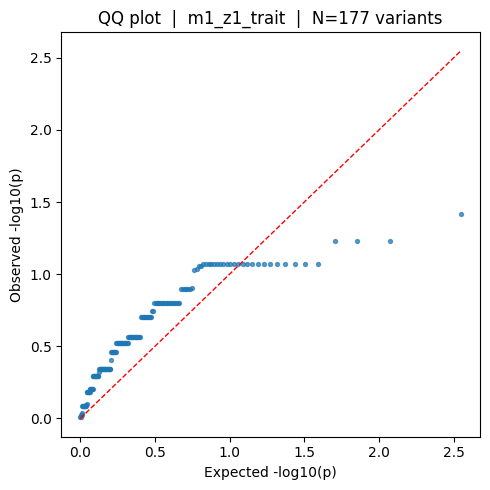

In [15]:
# Columns: #CHROM POS ID REF ALT A1 A1_FREQ TEST OBS_CT BETA SE T_STAT P ERRCODE
res = pd.read_csv(
    f"{VCF_FOLDER}/{RESULTS_FILE}.{TRAIT}.glm.linear", sep="\t"
)
print(f"Total variants tested: {len(res)}")

# Keep only testable variants: MAF > 10% (rare variants are unreliable with small N),
# and non-NaN p (NaN = monomorphic or collinear with a covariate).
testable = res[
    (res["A1_FREQ"] > 0.10) & (res["A1_FREQ"] < 0.90) & res["P"].notna()
].copy()
print(f"Testable variants (MAF > 10%, non-NaN p): {len(testable)}")

print("\nTop 10 associations:")
display(testable.sort_values("P").head(10))

# QQ plot: observed vs expected -log10(p) under the null (uniform)
p_vals   = testable["P"].sort_values().values
n        = len(p_vals)
expected = -np.log10((np.arange(1, n + 1) - 0.5) / n)
observed = -np.log10(p_vals)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(expected, observed, s=8, alpha=0.7)
ax.plot([0, expected.max()], [0, expected.max()], "r--", lw=1)
ax.set_xlabel("Expected -log10(p)")
ax.set_ylabel("Observed -log10(p)")
ax.set_title(f"QQ plot  |  {TRAIT}  |  N={n} variants")
plt.tight_layout(); plt.show()


## Follow-up on rs245013 (top candidate SNP)

`geno_dosage.raw` isn't produced by any cell above the original notebook reused it from --
generate it here with `plink2 --export A`, restricted by position since the exact
`--set-all-var-ids`-assigned ID isn't known ahead of time.

In [16]:
DOSAGE_FILE = "subset/plink/geno_dosage"
plink2(["--pfile", f"{SUBSET_PGEN}_qc",
        "--chr", "5", "--from-bp", "80751257", "--to-bp", "80751257",  # rs245013
        "--export", "A", "--out", DOSAGE_FILE])


PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to subset/plink/geno_dosage.log.
Options in effect:
  --chr 5
  --export A
  --from-bp 80751257
  --out subset/plink/geno_dosage
  --pfile subset/plink/candidate_qc
  --to-bp 80751257

Start time: Thu Jul 16 01:05:13 2026
314189 MiB RAM detected, ~243886 available; reserving 157094 MiB for main
workspace.
Using up to 48 threads (change this with --threads).
13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from
subset/plink/candidate_qc.psam.
138 out of 177 variants loaded from subset/plink/candidate_qc.pvar.
Note: No phenotype data present.
1 variant remaining after main filters.

--export A pass 1/1: loading... 0writing... 1523303846536169768492done.
--export A: subset/plink/geno_dosage.raw written.
End time: Thu Jul 16 01:05:13 2026



('PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/\n(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3\nLogging to subset/plink/geno_dosage.log.\nOptions in effect:\n  --chr 5\n  --export A\n  --from-bp 80751257\n  --out subset/plink/geno_dosage\n  --pfile subset/plink/candidate_qc\n  --to-bp 80751257\n\nStart time: Thu Jul 16 01:05:13 2026\n314189 MiB RAM detected, ~243886 available; reserving 157094 MiB for main\nworkspace.\nUsing up to 48 threads (change this with --threads).\n13 samples (0 females, 0 males, 13 ambiguous; 13 founders) loaded from\nsubset/plink/candidate_qc.psam.\n138 out of 177 variants loaded from subset/plink/candidate_qc.pvar.\nNote: No phenotype data present.\n1 variant remaining after main filters.\n\n--export A pass 1/1: loading... 0%\x08\x080%\x08\x08\x08\x08\x08\x08\x08\x08\x08\x08\x08\x08\x08writing... 0%\x08\x080%\x08\x087%\x08\x0815%\x08\x08\x0823%\x08\x08\x0830%\x08\x08\x0838%\x08\x08\x0846%\x08\x

SNP column: 5:80751257:A:C_A  ->  counting copies of 'A' allele

13 donors after merge
original_donor_id genotype  dosage  m1_z1_trait
       SCF-18-004       CC       0    -0.946457
       SCF-20-025       AC       1    -0.106301
       SCF-21-030       CC       0     0.026528
       SCF-18-003       CC       0    -0.946457
       SCF-20-023       AA       2     0.106301
       SCF-19-009       AA       2    -0.053075
       SCF_20-024       AC       1    -0.380326
       SCF_22-043       AA       2    -0.268441
       SCF-19-018       AC       1    -0.946457
       SCF-19-014       AC       1     0.213819
       SCF-18-006       CC       0    -0.946457
      PCMC-16-012       CC       0    -0.946457
       SCF-22-045       AC       1    -0.946457


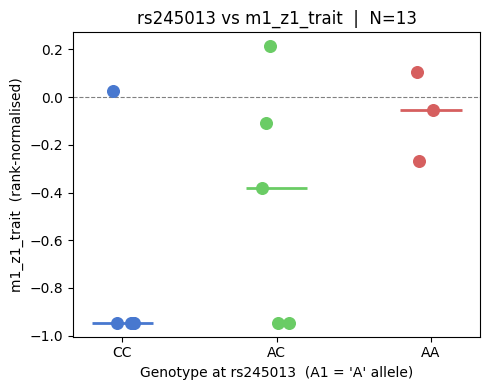


Spearman  rho = +0.530   p = 0.0624
  -> positive association: more 'A' alleles = higher m1_z1_trait

Permutation  p = 0.0632  (|rho| >= 0.530 in 100,000 shuffles)

-- Summary --
  Spearman p = 0.0624  |  Permutation p = 0.0632


In [17]:
from scipy import stats

# .raw file: one row per donor, one column per variant; dosage = number of A1 alleles (0, 1, or 2)
geno = pd.read_csv(f"{VCF_FOLDER}/{DOSAGE_FILE}.raw", sep="\t")

# Find the column for our SNP by position
snp_col = [c for c in geno.columns if ":80751257:" in c][0]
a1 = snp_col.split("_")[-1]   # A1 allele whose copies are counted (here: A)
print(f"SNP column: {snp_col}  ->  counting copies of '{a1}' allele")

# Keep only IID and dosage, rename to match df_meta_diseased
geno = (geno[["IID", snp_col]]
        .rename(columns={"IID": "original_donor_id", snp_col: "dosage"}))
geno["dosage"] = geno["dosage"].astype(int)

# Merge genotype with trait
df = df_meta_diseased.merge(geno, on="original_donor_id", how="inner")
print(f"\n{len(df)} donors after merge")

# Human-readable genotype label (e.g. dosage 1 -> "AC")
other = "C" if a1 == "A" else "A"
label_map = {0: f"{other}{other}", 1: f"{a1}{other}", 2: f"{a1}{a1}"}
df["genotype"] = df["dosage"].map(label_map)
print(df[["original_donor_id", "genotype", "dosage", "m1_z1_trait"]].to_string(index=False))

# Strip plot: every donor visible (small N is too small to hide in a boxplot)
fig, ax = plt.subplots(figsize=(5, 4))
groups = sorted(df["dosage"].unique())
palette = {0: "#4878CF", 1: "#6ACC65", 2: "#D65F5F"}

for g in groups:
    sub = df[df["dosage"] == g]["m1_z1_trait"]
    x = g + np.random.uniform(-0.1, 0.1, size=len(sub))  # jitter
    ax.scatter(x, sub, color=palette[g], s=70, zorder=3, label=label_map[g])
    ax.hlines(sub.median(), g - 0.2, g + 0.2, color=palette[g], linewidth=2, zorder=4)

ax.set_xticks(groups)
ax.set_xticklabels([label_map[g] for g in groups])
ax.set_xlabel(f"Genotype at rs245013  (A1 = '{a1}' allele)")
ax.set_ylabel("m1_z1_trait  (rank-normalised)")
ax.set_title(f"rs245013 vs m1_z1_trait  |  N={len(df)}")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.tight_layout(); plt.show()

# Spearman correlation: safer than OLS at small N, no normality assumption needed.
rho, p_spear = stats.spearmanr(df["dosage"], df["m1_z1_trait"])
print(f"\nSpearman  rho = {rho:+.3f}   p = {p_spear:.4f}")
print(f"  -> {'positive' if rho > 0 else 'negative'} association: "
      f"more '{a1}' alleles = {'higher' if rho > 0 else 'lower'} m1_z1_trait")

# Permutation p-value: exact p-value via 100,000 random trait shuffles.
np.random.seed(42)
n_perm = 100_000
obs = abs(rho)
null_rhos = [
    abs(stats.spearmanr(np.random.permutation(df["dosage"]), df["m1_z1_trait"])[0])
    for _ in range(n_perm)
]
p_perm = np.mean(np.array(null_rhos) >= obs)
print(f"\nPermutation  p = {p_perm:.4f}  (|rho| >= {obs:.3f} in {n_perm:,} shuffles)")

print("\n-- Summary --")
print(f"  Spearman p = {p_spear:.4f}  |  Permutation p = {p_perm:.4f}")


### Clinical variable correlations

A) Genotype (dosage) vs clinical variables
  age_of_onset          N=13  rho=+0.382  p=0.1978  
  age_of_death          N=13  rho=+0.077  p=0.8033  
  disease_duration      N=13  rho=-0.599  p=0.0304  *
  repeat_length         N=13  rho=-0.026  p=0.9317  

B) Trait (m1_z1_trait) vs clinical variables
  age_of_onset          N=13  rho=-0.120  p=0.6956  
  age_of_death          N=13  rho=-0.131  p=0.6698  
  disease_duration      N=13  rho=-0.518  p=0.0698  ~
  repeat_length         N=13  rho=+0.423  p=0.1498  


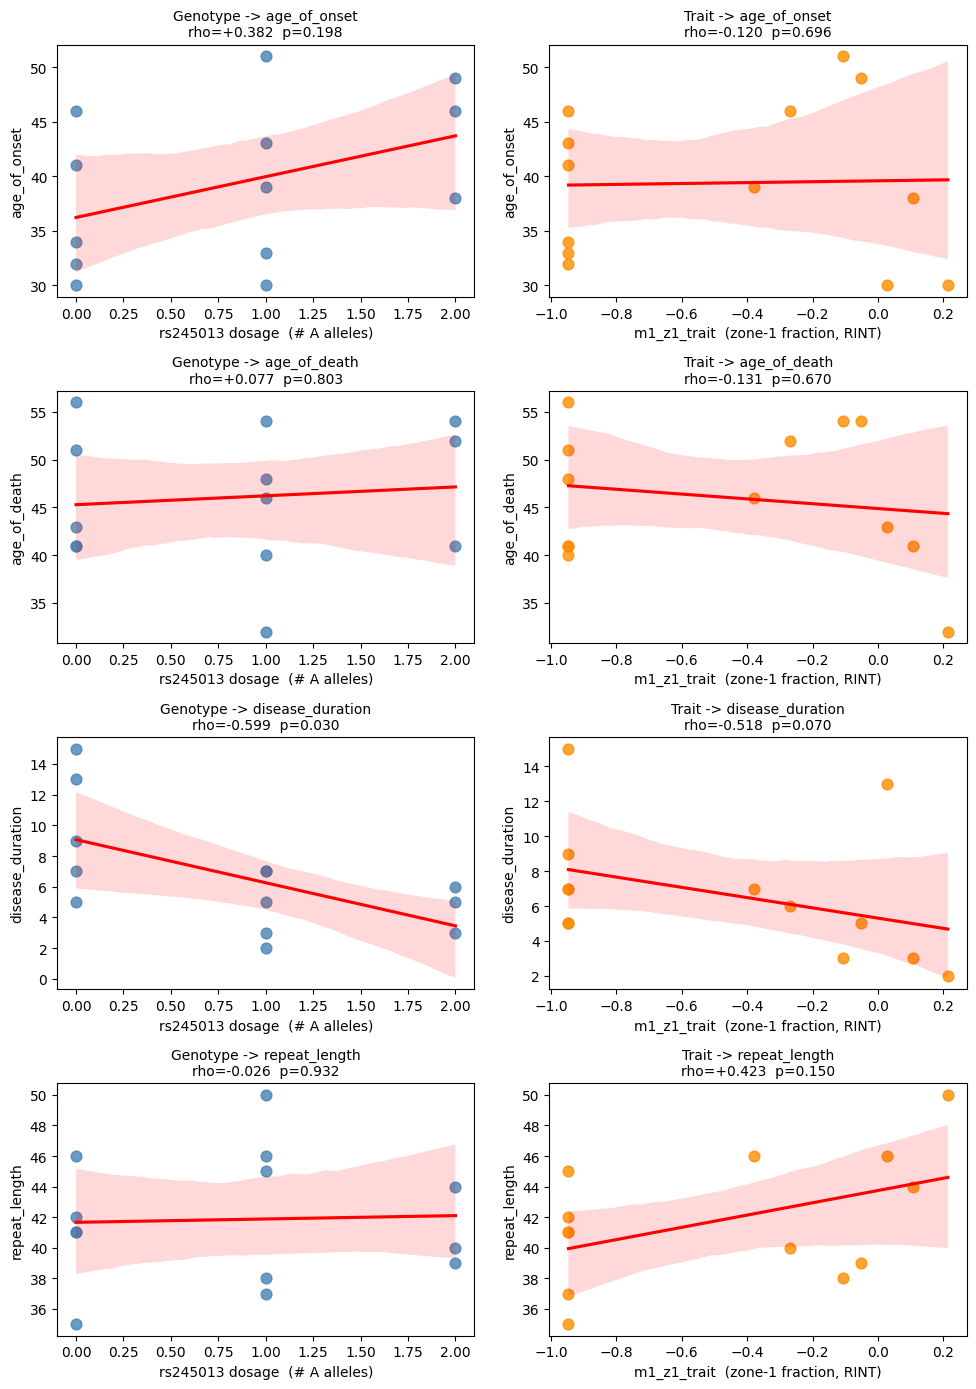

In [18]:
clinical_vars = ["age_of_onset", "age_of_death", "disease_duration", "repeat_length"]

df_clin = df.copy()   # df already has dosage + trait merged
for v in clinical_vars:
    df_clin[v] = pd.to_numeric(df_clin[v], errors="coerce")

# A) Is the GENOTYPE associated with clinical variables?
print("=" * 55)
print("A) Genotype (dosage) vs clinical variables")
print("=" * 55)

results_geno = []
for v in clinical_vars:
    sub = df_clin[["dosage", v]].dropna()
    if len(sub) < 5:
        print(f"  {v}: too few values ({len(sub)}), skip")
        continue
    rho, p = stats.spearmanr(sub["dosage"], sub[v])
    results_geno.append({"variable": v, "N": len(sub), "rho": rho, "p": p})
    sig = "*" if p < 0.05 else ("~" if p < 0.10 else "")
    print(f"  {v:<20}  N={len(sub)}  rho={rho:+.3f}  p={p:.4f}  {sig}")

# B) Is the TRAIT associated with clinical variables?
print()
print("=" * 55)
print("B) Trait (m1_z1_trait) vs clinical variables")
print("=" * 55)

results_trait = []
for v in clinical_vars:
    sub = df_clin[["m1_z1_trait", v]].dropna()
    if len(sub) < 5:
        continue
    rho, p = stats.spearmanr(sub["m1_z1_trait"], sub[v])
    results_trait.append({"variable": v, "N": len(sub), "rho": rho, "p": p})
    sig = "*" if p < 0.05 else ("~" if p < 0.10 else "")
    print(f"  {v:<20}  N={len(sub)}  rho={rho:+.3f}  p={p:.4f}  {sig}")

fig, axes = plt.subplots(len(clinical_vars), 2, figsize=(10, 3.5 * len(clinical_vars)))

for i, v in enumerate(clinical_vars):
    sub = df_clin[["dosage", "m1_z1_trait", v]].dropna()

    ax = axes[i, 0]
    sns.regplot(data=sub, x="dosage", y=v, ax=ax,
                scatter_kws={"s": 60, "color": "steelblue"},
                line_kws={"color": "red"})
    rho_g = next((r["rho"] for r in results_geno if r["variable"] == v), np.nan)
    p_g   = next((r["p"]   for r in results_geno if r["variable"] == v), np.nan)
    ax.set_xlabel("rs245013 dosage  (# A alleles)")
    ax.set_ylabel(v)
    ax.set_title(f"Genotype -> {v}\nrho={rho_g:+.3f}  p={p_g:.3f}", fontsize=10)

    ax2 = axes[i, 1]
    sns.regplot(data=sub, x="m1_z1_trait", y=v, ax=ax2,
                scatter_kws={"s": 60, "color": "darkorange"},
                line_kws={"color": "red"})
    rho_t = next((r["rho"] for r in results_trait if r["variable"] == v), np.nan)
    p_t   = next((r["p"]   for r in results_trait if r["variable"] == v), np.nan)
    ax2.set_xlabel("m1_z1_trait  (zone-1 fraction, RINT)")
    ax2.set_ylabel(v)
    ax2.set_title(f"Trait -> {v}\nrho={rho_t:+.3f}  p={p_t:.3f}", fontsize=10)

plt.tight_layout()
plt.show()


### IGV browser (TAF1 region)

In [19]:
import igv_notebook
igv_notebook.init()
b = igv_notebook.Browser({
    "genome": "hg38",
    "locus": "chrX:71,366,131-71,532,374",
    "tracks": [{
        "name": "TAF1",
        "path": "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam",
        "indexPath": "/home/gdallagl/myworkdir/XDP/data/XDP/SlideTags_dataset/SlideTags_single_libraries/sample_02/260313_SL-EXA_0758_B23GHNHLT4/SI-TT-C1/bam/taf1_subset.bam.bai",
        "format": "bam",
        "type": "alignment"
    }]
})


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### rsID lookup

In [20]:
import requests

def get_rsid(chrom, pos, ref, alt):
    # Format the query as HGVS (e.g., chr5:g.77178682G>A)
    hgvs = f"chr{chrom}:g.{pos}{ref}>{alt}"

    # Query MyVariant.info API (defaults to hg38; use assembly=hg19 parameter if needed)
    url = f"https://myvariant.info/v1/variant/{hgvs}?fields=dbsnp.rsid"

    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        return data.get("dbsnp", {}).get("rsid", "No rsID found")
    else:
        return "Variant not found or query failed"

rs_name = get_rsid(5, 77178682, 'G', 'A')
print(f"The rsID is: {rs_name}")


The rsID is: Variant not found or query failed
